In [39]:
# Cell 1 — Imports + base settings
from pathlib import Path
import re
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


In [40]:
# Cell 2 — Configure your project path (edit if needed)
BASE_DIR = Path(r"/Users/khuedinh/Documents/ALY_6110/")
BASE_DIR.exists(), BASE_DIR


(True, PosixPath('/Users/khuedinh/Documents/ALY_6110'))

In [41]:
# Cell 3 — Identify state-year folders (CA-2021, etc.)
FOLDER_RE = re.compile(r"^(?P<state>[A-Z]{2})-(?P<year>\d{4})$")

state_year_dirs = []
for p in BASE_DIR.iterdir():
    if p.is_dir():
        m = FOLDER_RE.match(p.name)
        if m:
            state_year_dirs.append((p, m.group("state"), int(m.group("year"))))

state_year_dirs = sorted(state_year_dirs, key=lambda x: (x[1], x[2]))  # sort by state, year
len(state_year_dirs), state_year_dirs[:5]


(16,
 [(PosixPath('/Users/khuedinh/Documents/ALY_6110/CA-2021'), 'CA', 2021),
  (PosixPath('/Users/khuedinh/Documents/ALY_6110/CA-2022'), 'CA', 2022),
  (PosixPath('/Users/khuedinh/Documents/ALY_6110/CA-2023'), 'CA', 2023),
  (PosixPath('/Users/khuedinh/Documents/ALY_6110/CA-2024'), 'CA', 2024),
  (PosixPath('/Users/khuedinh/Documents/ALY_6110/ID-2021'), 'ID', 2021)])

In [42]:
# Cell 4 — Quick validation: list files in one folder (optional)
sample_folder, sample_state, sample_year = state_year_dirs[0]
sample_folder, sample_state, sample_year, [f.name for f in sample_folder.iterdir()][:10]


(PosixPath('/Users/khuedinh/Documents/ALY_6110/CA-2021'),
 'CA',
 2021,
 ['NIBRS_PROP_DESC_TYPE.csv',
  'NIBRS_WEAPON_TYPE.csv',
  'NIBRS_ASSIGNMENT_TYPE.csv',
  'REF_RACE.csv',
  'NIBRS_ARREST_TYPE.csv',
  'NIBRS_SUSPECTED_DRUG.csv',
  'postgres_load.sql',
  'NIBRS_AGE.csv',
  'NIBRS_INJURY.csv',
  'NIBRS_ARRESTEE.csv'])

In [43]:
# Cell 5 — Define which tables to load (fact tables + lookups)
FACT_FILES = {
    "incident": "NIBRS_incident.csv",
    "offense": "NIBRS_OFFENSE.csv",
    "victim": "NIBRS_VICTIM.csv",
    "offender": "NIBRS_OFFENDER.csv",
    "arrestee": "NIBRS_ARRESTEE.csv",
    "weapon": "NIBRS_WEAPON.csv",
}

LOOKUP_FILES = {
    "offense_type": "NIBRS_OFFENSE_TYPE.csv",
    "location_type": "NIBRS_LOCATION_TYPE.csv",
    "weapon_type": "NIBRS_WEAPON_TYPE.csv",
    "race": "REF_RACE.csv",
    "state": "REF_STATE.csv",
    "ethnicity": "NIBRS_ETHNICITY.csv",
    "victim_type": "NIBRS_VICTIM_TYPE.csv",
    "month": "NIBRS_month.csv",
}

# Read as strings first to avoid dtype headaches; we'll cast later.
READ_KWARGS = dict(dtype="string", low_memory=False)


In [44]:
# Cell 6 — Check that every folder contains the required fact files
missing = []
for folder, st, yr in state_year_dirs:
    for key, fname in FACT_FILES.items():
        if not (folder / fname).exists():
            missing.append((folder.name, fname))

len(missing), missing[:10]


(0, [])

In [45]:
# Cell 7 — Helper to load one fact table across all folders (adds state/year + lowercases cols)

def load_fact_table(table_key: str) -> pd.DataFrame:
    fname = FACT_FILES[table_key]
    parts = []
    for folder, st, yr in state_year_dirs:
        path = folder / fname
        df = pd.read_csv(path, dtype="string", low_memory=False)

        # Normalize columns immediately (no copy)
        df.columns = [c.strip().lower() for c in df.columns]

        # Add partition columns
        df["state"] = st
        df["year"] = yr

        parts.append(df)

    return pd.concat(parts, ignore_index=True)


In [46]:
# Cell 8 — Load INCIDENT (this may take a bit depending on size)
df_incident = load_fact_table("incident")
df_incident.shape, df_incident.head(3)


((4799260, 17),
   data_year agency_id incident_id nibrs_month_id cargo_theft_flag          submission_date incident_date report_date_flag incident_hour  \
 0      2021      1516   141774651       40314544                f  2021-09-03 15:14:09.574    2021-08-26                f            12   
 1      2021      1516   136500530        3105156                f  2021-04-01 16:21:26.134    2021-01-01                f             0   
 2      2021      1516   136580646        3105156                f  2021-04-07 16:16:36.326    2021-01-01                f             0   
 
   cleared_except_id cleared_except_date incident_status data_home orig_format        did state  year  
 0                 6                <NA>        ACCEPTED      <NA>           X  110753366    CA  2021  
 1                 6                <NA>        ACCEPTED      <NA>           X   99192428    CA  2021  
 2                 6                <NA>        ACCEPTED      <NA>           X   99434989    CA  2021  )

In [47]:
# Cell 9 — Load OFFENSE
df_offense = load_fact_table("offense")
df_offense.shape, df_offense.head(3)


((5472395, 10),
   data_year offense_id incident_id offense_code attempt_complete_flag location_id num_premises_entered method_entry_code state  year
 0      2021  170403568   141774651          11A                     C          35                 <NA>              <NA>    CA  2021
 1      2021  164352006   136500530          13A                     C          25                 <NA>              <NA>    CA  2021
 2      2021  164444800   136580646          13B                     C          35                 <NA>              <NA>    CA  2021)

In [48]:
# Cell 10 — Load VICTIM
df_victim = load_fact_table("victim")
df_victim.shape, df_victim.head(3)


((5446008, 18),
   data_year  victim_id incident_id victim_seq_num victim_type_id assignment_type_id activity_type_id outside_agency_id age_id age_num  \
 0      2021  156137715   141774651              1              4               <NA>             <NA>              <NA>     32      29   
 1      2021  150097155   136500530              1              4               <NA>             <NA>              <NA>     20      17   
 2      2021  150188607   136580646              1              4               <NA>             <NA>              <NA>     41      38   
 
   sex_code race_id ethnicity_id resident_status_code age_range_low_num age_code_range_high state  year  
 0        F      10           20                    R                29                <NA>    CA  2021  
 1        M      10           10                    R                17                <NA>    CA  2021  
 2        M      10           20                    R                38                <NA>    CA  2021  )

In [49]:
# Cell 11 — Load OFFENDER
df_offender = load_fact_table("offender")
df_offender.shape, df_offender.head(3)


((5330884, 13),
   data_year offender_id incident_id offender_seq_num age_id age_num sex_code race_id ethnicity_id age_range_low_num age_range_high_num  \
 0      2021   161073930   141774651                1     36      33        M      10           20                33               <NA>   
 1      2021   155090892   136500530                1     31      28        M      10           10                28               <NA>   
 2      2021   155181712   136580646                1     39      36        F      10           20                36               <NA>   
 
   state  year  
 0    CA  2021  
 1    CA  2021  
 2    CA  2021  )

In [50]:
# Cell 12 — Load ARRESTEE
df_arrestee = load_fact_table("arrestee")
df_arrestee.shape, df_arrestee.head(3)


((1376900, 20),
   data_year arrestee_id incident_id arrestee_seq_num arrest_date arrest_type_id multiple_indicator offense_code age_id age_num sex_code  \
 0      2021    42182498   136580646                1  2021-01-01              1                  N          90Z     39      36        F   
 1      2021    42171748   136530548                1  2021-01-01              1                  N          13B     43      40        F   
 2      2021    42375950   137248920                1  2021-01-01              1                  N          280     47      44        F   
 
   race_id ethnicity_id resident_code under_18_disposition_code clearance_ind age_range_low_num age_range_high_num state  year  
 0      10           50             R                      <NA>          <NA>                36               <NA>    CA  2021  
 1      10           50             U                      <NA>          <NA>                40               <NA>    CA  2021  
 2      20           50            

In [51]:
# Cell 13 — Load WEAPON (links to OFFENSE_ID)
df_weapon = load_fact_table("weapon")
df_weapon.shape, df_weapon.head(3)


((1335603, 6),
   data_year weapon_id offense_id nibrs_weapon_id state  year
 0      2021        41  170403568            <NA>    CA  2021
 1      2021        32  164352006            <NA>    CA  2021
 2      2021        41  164444800            <NA>    CA  2021)

In [52]:
# Cell 14 — Helper to load lookup tables once (lowercases cols immediately)

def load_lookup_table(lookup_key: str) -> pd.DataFrame:
    fname = LOOKUP_FILES[lookup_key]
    for folder, _, _ in state_year_dirs:
        path = folder / fname
        if path.exists():
            df = pd.read_csv(path, dtype="string", low_memory=False)
            df.columns = [c.strip().lower() for c in df.columns]
            return df
    raise FileNotFoundError(f"Lookup file not found in any folder: {fname}")


In [53]:
# Cell 15 — Load lookup tables
lk_offense_type  = load_lookup_table("offense_type")
lk_location_type = load_lookup_table("location_type")
lk_weapon_type   = load_lookup_table("weapon_type")
lk_race          = load_lookup_table("race")
lk_state         = load_lookup_table("state")
lk_ethnicity     = load_lookup_table("ethnicity")
lk_victim_type   = load_lookup_table("victim_type")
lk_month         = load_lookup_table("month")

(lk_offense_type.shape, lk_location_type.shape, lk_weapon_type.shape)


((86, 8), (47, 3), (28, 4))

In [54]:
# Cell 16 — Required column checks (lowercase)

def assert_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

assert_cols(df_incident, ["incident_id", "nibrs_month_id"], "df_incident")
assert_cols(df_offense,  ["offense_id", "incident_id", "offense_code", "location_id"], "df_offense")
assert_cols(df_weapon,   ["offense_id", "weapon_id"], "df_weapon")

print("✅ Required columns present.")


✅ Required columns present.


In [55]:
lk_month["nibrs_month_id"].value_counts().head(10)


40302022    4804
40333481    4666
40281448    4647
40324400    4584
3141072     4516
40314543    4500
3141071     4499
40293001    4453
40349912    4439
40272407    4377
Name: nibrs_month_id, dtype: Int64

In [56]:
# Cell 17 — Fix month lookup uniqueness + build offense_view safely

# 1) offense -> offense_type
offense_view = df_offense.merge(
    lk_offense_type[["offense_code", "offense_name", "offense_category_name", "crime_against"]],
    on="offense_code",
    how="left",
    validate="m:1"
)

# 2) offense -> location_type
offense_view = offense_view.merge(
    lk_location_type[["location_id", "location_name"]],
    on="location_id",
    how="left",
    validate="m:1"
)

# 3) offense -> incident
offense_view = offense_view.merge(
    df_incident[["incident_id", "incident_date", "incident_hour", "nibrs_month_id", "state", "year"]],
    on=["incident_id", "state", "year"],
    how="left",
    validate="m:1"
)

# ---- KEY FIX: make a unique month lookup keyed by nibrs_month_id ----
month_lk = (
    lk_month[["nibrs_month_id", "month_num", "data_year"]]
    .drop_duplicates(subset=["nibrs_month_id"])
)

# 4) incident -> month (now m:1 is valid)
offense_view = offense_view.merge(
    month_lk,
    on="nibrs_month_id",
    how="left",
    validate="m:1"
)

offense_view.shape, offense_view.head(3)


((5472395, 19),
   data_year_x offense_id incident_id offense_code attempt_complete_flag location_id num_premises_entered method_entry_code state  year  \
 0        2021  170403568   141774651          11A                     C          35                 <NA>              <NA>    CA  2021   
 1        2021  164352006   136500530          13A                     C          25                 <NA>              <NA>    CA  2021   
 2        2021  164444800   136580646          13B                     C          35                 <NA>              <NA>    CA  2021   
 
          offense_name offense_category_name crime_against                       location_name incident_date incident_hour nibrs_month_id  \
 0                Rape          Sex Offenses        Person                      Residence/Home    2021-08-26            12       40314544   
 1  Aggravated Assault      Assault Offenses        Person  Highway/Road/Alley/Street/Sidewalk    2021-01-01             0        3105156   
 2 

In [57]:
# Cell 18 — Cleanup duplicate year columns + quick sanity checks

# Keep one authoritative data_year (use incident/offense one)
# data_year_x came from df_offense; data_year_y came from month_lk
offense_view = offense_view.rename(columns={"data_year_x": "data_year_offense", "data_year_y": "data_year_month"})

# Optional: check if they disagree (good data quality check)
year_mismatch = (offense_view["data_year_offense"].notna() &
                 offense_view["data_year_month"].notna() &
                 (offense_view["data_year_offense"] != offense_view["data_year_month"])).sum()

print("Rows where offense data_year != month data_year:", year_mismatch)

# Create a single data_year column (prefer offense)
offense_view["data_year"] = offense_view["data_year_offense"]

# Drop the redundant columns
offense_view = offense_view.drop(columns=["data_year_offense", "data_year_month"])

# Basic sanity: missing labels?
print("Missing offense_name:", offense_view["offense_name"].isna().mean())
print("Missing location_name:", offense_view["location_name"].isna().mean())

offense_view.shape, offense_view.head(3)


Rows where offense data_year != month data_year: 0
Missing offense_name: 0.0
Missing location_name: 0.0


((5472395, 18),
   offense_id incident_id offense_code attempt_complete_flag location_id num_premises_entered method_entry_code state  year  \
 0  170403568   141774651          11A                     C          35                 <NA>              <NA>    CA  2021   
 1  164352006   136500530          13A                     C          25                 <NA>              <NA>    CA  2021   
 2  164444800   136580646          13B                     C          35                 <NA>              <NA>    CA  2021   
 
          offense_name offense_category_name crime_against                       location_name incident_date incident_hour nibrs_month_id  \
 0                Rape          Sex Offenses        Person                      Residence/Home    2021-08-26            12       40314544   
 1  Aggravated Assault      Assault Offenses        Person  Highway/Road/Alley/Street/Sidewalk    2021-01-01             0        3105156   
 2      Simple Assault      Assault Offenses       

In [58]:
# Cell 19 — High-level EDA summaries (fast, informative)

# 1) Rows by state and year (scale check)
rows_by_state_year = (
    offense_view
    .groupby(["state", "data_year"])
    .size()
    .reset_index(name="offense_count")
    .sort_values(["state", "data_year"])
)

rows_by_state_year


,state,data_year,offense_count
0,CA,2021,136848
1,CA,2022,848369
2,CA,2023,1239106
3,CA,2024,1369571
4,ID,2021,73420
5,ID,2022,76626
6,ID,2023,73294
7,ID,2024,69156
8,MA,2021,212959
9,MA,2022,217004


In [59]:
# 2) Top offense categories overall
top_offense_categories = (
    offense_view
    .groupby("offense_category_name")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_offense_categories.head(10)


,offense_category_name,count
15,Larceny/Theft Offenses,1481753
2,Assault Offenses,1118556
7,Drug/Narcotic Offenses,665343
6,Destruction/Damage/Vandalism of Property,600699
10,Fraud Offenses,418588
16,Motor Vehicle Theft,350481
4,Burglary/Breaking & Entering,289289
24,Weapon Law Violations,135649
20,Robbery,91383
21,Sex Offenses,79453


In [60]:
# 3) Monthly distribution (seasonality check)
monthly_distribution = (
    offense_view
    .groupby("month_num")
    .size()
    .reset_index(name="count")
    .sort_values("month_num")
)

monthly_distribution


,month_num,count
0,1,9956
1,10,11834
2,11,10931
3,12,10902
4,2,11429
5,3,11597
6,4,11367
7,5,12088
8,6,11429
9,7,12267


In [61]:
# Cell 20 — Year-over-year trends by offense category

yearly_category_trends = (
    offense_view
    .groupby(["data_year", "offense_category_name"])
    .size()
    .reset_index(name="offense_count")
    .sort_values(["offense_category_name", "data_year"])
)

yearly_category_trends.head(10)


,data_year,offense_category_name,offense_count
0,2021,Animal Cruelty,332
25,2022,Animal Cruelty,1047
50,2023,Animal Cruelty,1527
75,2024,Animal Cruelty,1911
1,2021,Arson,954
26,2022,Arson,4131
51,2023,Arson,5219
76,2024,Arson,6276
2,2021,Assault Offenses,114784
27,2022,Assault Offenses,255357


In [62]:
# Cell 21 — Crime Against type trends

crime_against_trends = (
    offense_view
    .groupby(["data_year", "crime_against"])
    .size()
    .reset_index(name="offense_count")
    .sort_values(["crime_against", "data_year"])
)

crime_against_trends


,data_year,crime_against,offense_count
0,2021,Person,125505
3,2022,Person,282463
6,2023,Person,379514
9,2024,Person,447021
1,2021,Property,300211
4,2022,Property,837904
7,2023,Property,1113215
10,2024,Property,1160277
2,2021,Society,73687
5,2022,Society,199334


In [63]:
# Cell 22 — State-level yearly trends

state_year_trends = (
    offense_view
    .groupby(["state", "data_year"])
    .size()
    .reset_index(name="offense_count")
    .sort_values(["state", "data_year"])
)

state_year_trends


,state,data_year,offense_count
0,CA,2021,136848
1,CA,2022,848369
2,CA,2023,1239106
3,CA,2024,1369571
4,ID,2021,73420
5,ID,2022,76626
6,ID,2023,73294
7,ID,2024,69156
8,MA,2021,212959
9,MA,2022,217004


In [64]:
import matplotlib.pyplot as plt

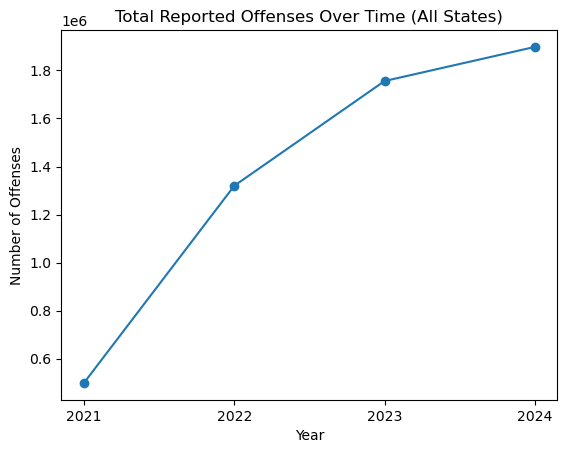

In [65]:
# Cell 23 — Total offenses by year (all states)

yearly_total = (
    offense_view
    .groupby("data_year")
    .size()
    .reset_index(name="offense_count")
)

plt.figure()
plt.plot(yearly_total["data_year"], yearly_total["offense_count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Offenses")
plt.title("Total Reported Offenses Over Time (All States)")
plt.show()


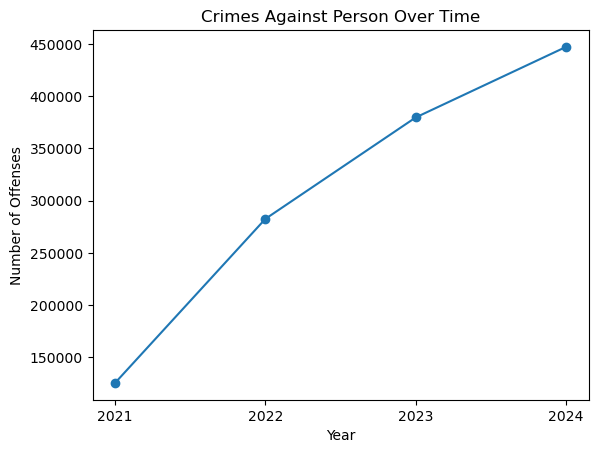

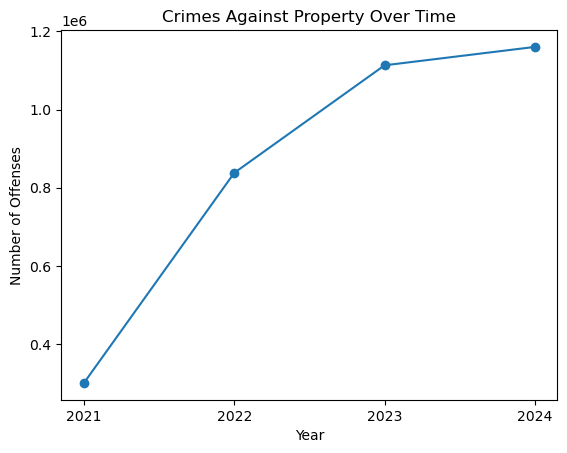

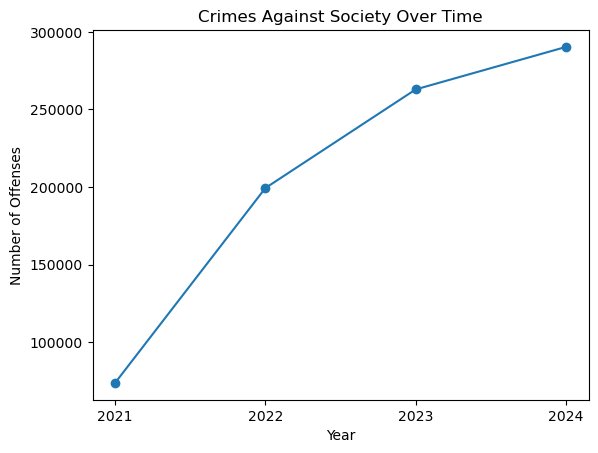

In [66]:
# Cell 24 — Crime Against trends over time

crime_against_trends = (
    offense_view
    .groupby(["data_year", "crime_against"])
    .size()
    .reset_index(name="offense_count")
)

for ca in crime_against_trends["crime_against"].unique():
    subset = crime_against_trends[crime_against_trends["crime_against"] == ca]
    plt.figure()
    plt.plot(subset["data_year"], subset["offense_count"], marker="o")
    plt.xlabel("Year")
    plt.ylabel("Number of Offenses")
    plt.title(f"Crimes Against {ca} Over Time")
    plt.show()


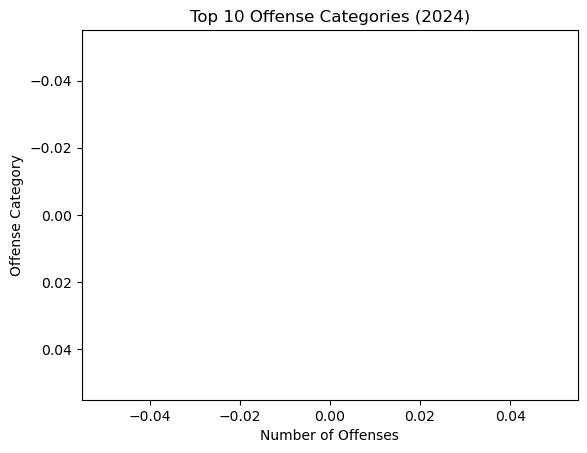

In [67]:
# Cell 25 — Top offense categories in 2024

top_2024 = (
    offense_view[offense_view["data_year"] == 2024]
    .groupby("offense_category_name")
    .size()
    .reset_index(name="offense_count")
    .sort_values("offense_count", ascending=False)
    .head(10)
)

plt.figure()
plt.barh(top_2024["offense_category_name"], top_2024["offense_count"])
plt.xlabel("Number of Offenses")
plt.ylabel("Offense Category")
plt.title("Top 10 Offense Categories (2024)")
plt.gca().invert_yaxis()
plt.show()


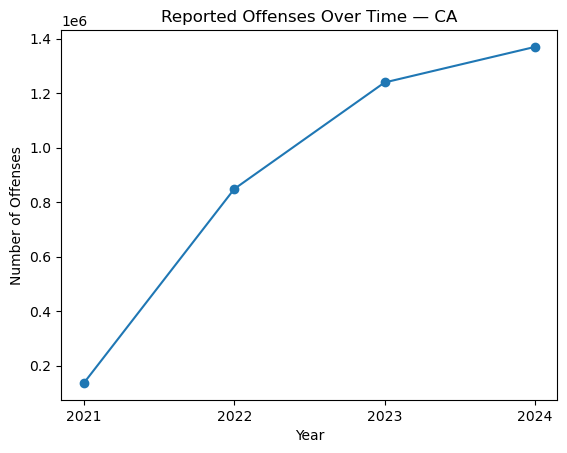

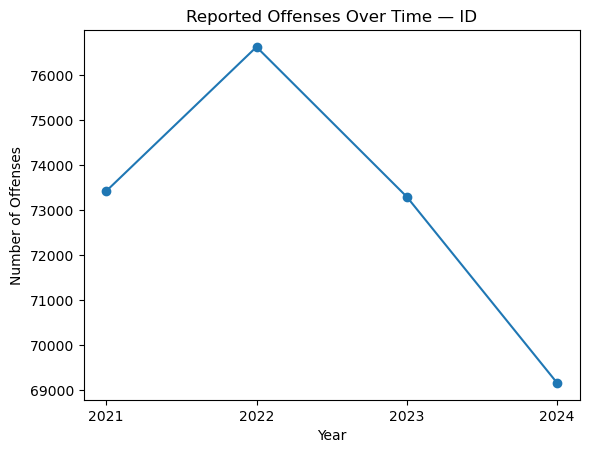

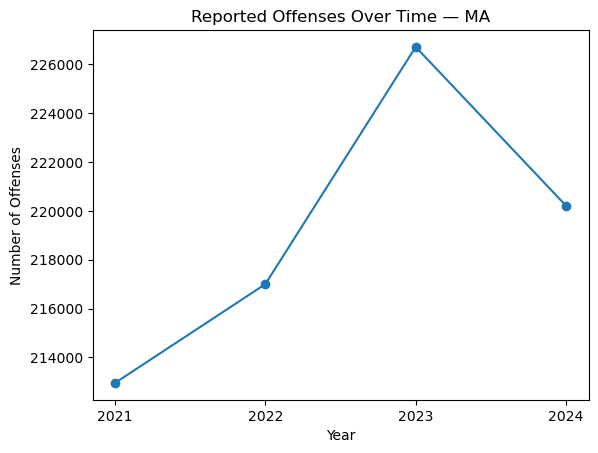

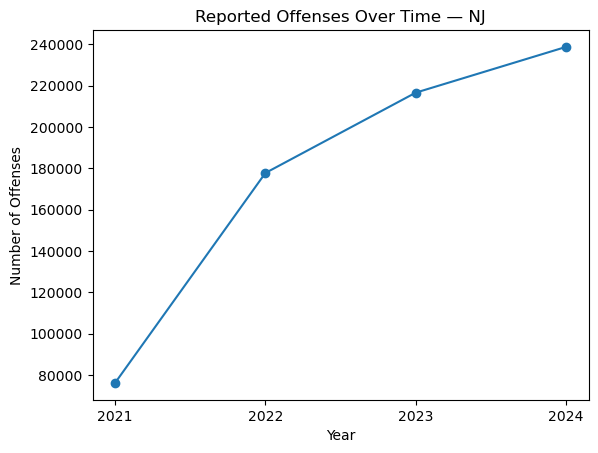

In [68]:
# Cell 26 — State-level offense trends

state_trends = (
    offense_view
    .groupby(["state", "data_year"])
    .size()
    .reset_index(name="offense_count")
)

for st in state_trends["state"].unique():
    subset = state_trends[state_trends["state"] == st]
    plt.figure()
    plt.plot(subset["data_year"], subset["offense_count"], marker="o")
    plt.xlabel("Year")
    plt.ylabel("Number of Offenses")
    plt.title(f"Reported Offenses Over Time — {st}")
    plt.show()


In [69]:
# Cell 27 — Prepare victim base table (minimal columns)

victim_base = df_victim[[
    "victim_id",
    "incident_id",
    "age_num",
    "sex_code",
    "race_id",
    "ethnicity_id",
    "state",
    "year"
]].copy()

victim_base.shape, victim_base.head(3)


((5446008, 8),
    victim_id incident_id age_num sex_code race_id ethnicity_id state  year
 0  156137715   141774651      29        F      10           20    CA  2021
 1  150097155   136500530      17        M      10           10    CA  2021
 2  150188607   136580646      38        M      10           20    CA  2021)

In [70]:
# Cell 28 — Join victims to incident (date + month context)

victim_base = victim_base.merge(
    df_incident[["incident_id", "incident_date", "nibrs_month_id", "state", "year"]],
    on=["incident_id", "state", "year"],
    how="left",
    validate="m:1"
)

victim_base.shape, victim_base.head(3)


((5446008, 10),
    victim_id incident_id age_num sex_code race_id ethnicity_id state  year incident_date nibrs_month_id
 0  156137715   141774651      29        F      10           20    CA  2021    2021-08-26       40314544
 1  150097155   136500530      17        M      10           10    CA  2021    2021-01-01        3105156
 2  150188607   136580646      38        M      10           20    CA  2021    2021-01-01        3105156)

In [71]:
lk_race.columns.tolist()

['race_id',
 'race_code',
 'race_desc',
 'sort_order',
 'start_year',
 'end_year',
 'notes']

In [72]:
# Cell 29 — Decode race and ethnicity (using actual columns)

victim_base = victim_base.merge(
    lk_race[["race_id", "race_desc"]].rename(columns={"race_desc": "race"}),
    on="race_id",
    how="left",
    validate="m:1"
)

# Check ethnicity columns once (quick)
lk_ethnicity.columns.tolist()


['ethnicity_id', 'ethnicity_code', 'ethnicity_name']

In [73]:
# Cell 30 — Decode ethnicity + sanity check

victim_base = victim_base.merge(
    lk_ethnicity[["ethnicity_id", "ethnicity_name"]].rename(columns={"ethnicity_name": "ethnicity"}),
    on="ethnicity_id",
    how="left",
    validate="m:1"
)

victim_base[["race", "ethnicity", "sex_code", "age_num"]].head(5)


,race,ethnicity,sex_code,age_num
0,White,Not Hispanic or Latino,F,29
1,White,Hispanic or Latino,M,17
2,White,Not Hispanic or Latino,M,38
3,Black or African American,Not Hispanic or Latino,M,42
4,White,Not Hispanic or Latino,F,31


In [74]:
# Cell 31a — Victims by sex
victims_by_sex = (
    victim_base
    .groupby("sex_code")
    .size()
    .reset_index(name="victim_count")
    .sort_values("victim_count", ascending=False)
)
victims_by_sex


,sex_code,victim_count
1,M,1971861
0,F,1824182
3,X,1593201
2,U,56764


In [75]:
# Cell 31b — Victims by race (top 10)
victims_by_race = (
    victim_base
    .groupby("race")
    .size()
    .reset_index(name="victim_count")
    .sort_values("victim_count", ascending=False)
    .head(10)
)
victims_by_race


,race,victim_count
6,White,2667358
4,Not Specified,1593201
2,Black or African American,491607
5,Unknown,387112
1,Asian,272888
0,American Indian or Alaska Native,19016
3,Native Hawaiian or Other Pacific Islander,14826


In [76]:
# Cell 31c — Victims by ethnicity
victims_by_ethnicity = (
    victim_base
    .groupby("ethnicity")
    .size()
    .reset_index(name="victim_count")
    .sort_values("victim_count", ascending=False)
)
victims_by_ethnicity


,ethnicity,victim_count
2,Not Specified,2104809
1,Not Hispanic or Latino,1973160
0,Hispanic or Latino,989922
3,Unknown,378117


In [77]:
# Cell 32 — Victim age bins (NOTE: age_num is string, convert safely)

age_bins = [0, 12, 17, 24, 34, 44, 54, 64, 120]
age_labels = ["0–12","13–17","18–24","25–34","35–44","45–54","55–64","65+"]

victim_base["age_num_float"] = pd.to_numeric(victim_base["age_num"], errors="coerce")

victim_base["age_group"] = pd.cut(
    victim_base["age_num_float"],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

victims_by_age_group = (
    victim_base
    .groupby("age_group")
    .size()
    .reset_index(name="victim_count")
)

victims_by_age_group


,age_group,victim_count
0,0–12,168636
1,13–17,157231
2,18–24,446214
3,25–34,875038
4,35–44,773215
5,45–54,576073
6,55–64,457350
7,65+,393296


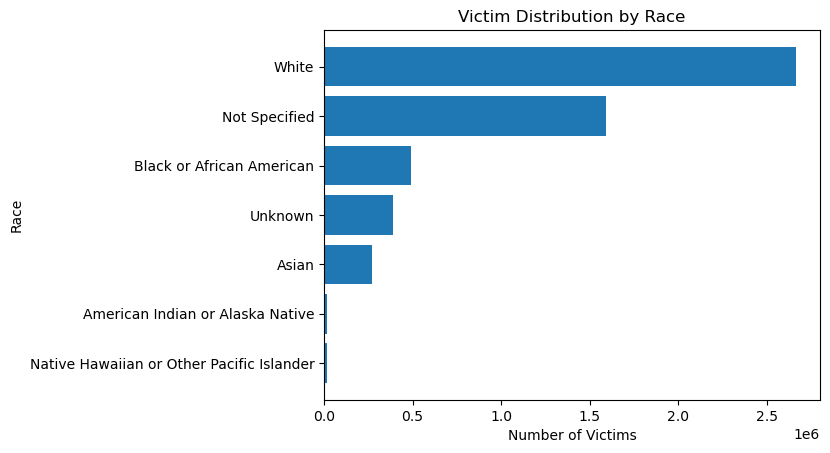

In [78]:
# Cell 33 — Victims by race (distribution)

plt.figure()
plt.barh(victims_by_race["race"], victims_by_race["victim_count"])
plt.xlabel("Number of Victims")
plt.ylabel("Race")
plt.title("Victim Distribution by Race")
plt.gca().invert_yaxis()
plt.show()


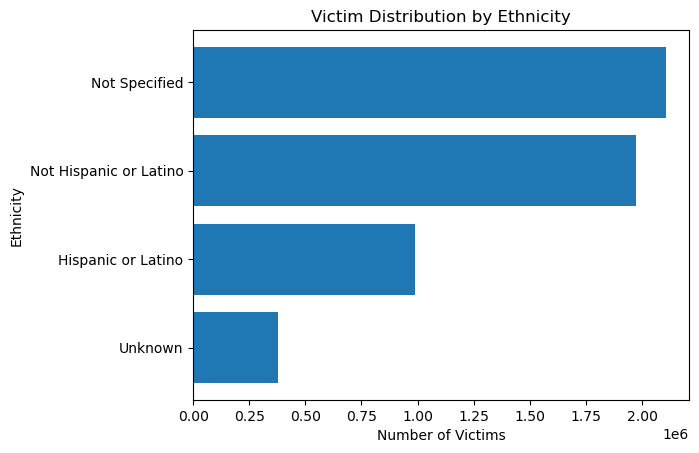

In [79]:
# Cell 34 — Victims by ethnicity

plt.figure()
plt.barh(victims_by_ethnicity["ethnicity"], victims_by_ethnicity["victim_count"])
plt.xlabel("Number of Victims")
plt.ylabel("Ethnicity")
plt.title("Victim Distribution by Ethnicity")
plt.gca().invert_yaxis()
plt.show()


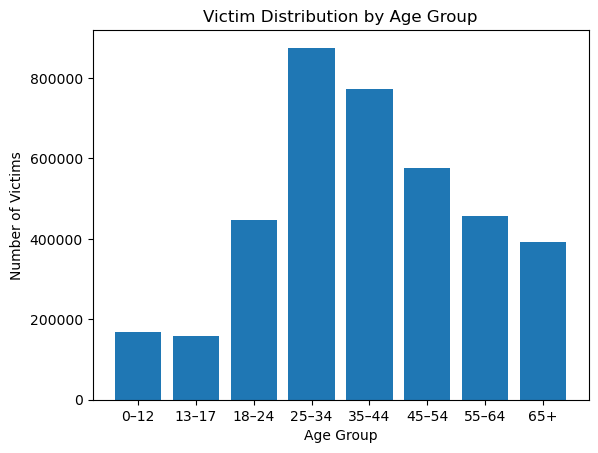

In [80]:
# Cell 35 — Victim age distribution

plt.figure()
plt.bar(victims_by_age_group["age_group"], victims_by_age_group["victim_count"])
plt.xlabel("Age Group")
plt.ylabel("Number of Victims")
plt.title("Victim Distribution by Age Group")
plt.show()


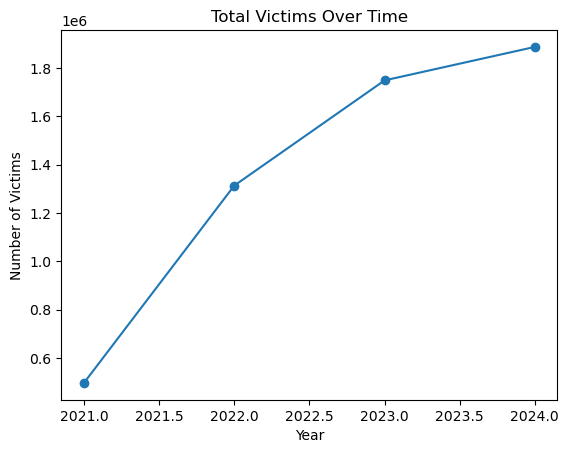

In [81]:
# Cell 36 — Victim counts by year

victims_over_time = (
    victim_base
    .groupby("year")
    .size()
    .reset_index(name="victim_count")
    .sort_values("year")
)

plt.figure()
plt.plot(victims_over_time["year"], victims_over_time["victim_count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Victims")
plt.title("Total Victims Over Time")
plt.show()


In [82]:
# Cell 37 — Load victim-offense bridge table

df_victim_offense = load_fact_table("victim_offense") if "victim_offense" in FACT_FILES else None

# If not in FACT_FILES yet, load manually
if df_victim_offense is None:
    parts = []
    for folder, st, yr in state_year_dirs:
        path = folder / "NIBRS_VICTIM_OFFENSE.csv"
        df = pd.read_csv(path, dtype="string", low_memory=False)
        df.columns = [c.strip().lower() for c in df.columns]
        df["state"] = st
        df["year"] = yr
        parts.append(df)
    df_victim_offense = pd.concat(parts, ignore_index=True)

df_victim_offense.shape, df_victim_offense.head(3)


((5952426, 5),
   data_year  victim_id offense_id state  year
 0      2021  156137715  170403568    CA  2021
 1      2021  150097155  164352006    CA  2021
 2      2021  150188607  164444800    CA  2021)

In [83]:
# Cell 38 — Victim demographics by offense category (SAFE aggregation)

victim_offense_demo = (
    df_victim_offense
    .merge(
        victim_base[[
            "victim_id", "race", "ethnicity", "sex_code", "age_group", "state", "year"
        ]],
        on=["victim_id", "state", "year"],
        how="left",
        validate="m:1"
    )
    .merge(
        offense_view[[
            "offense_id", "offense_category_name", "crime_against", "state", "year"
        ]],
        on=["offense_id", "state", "year"],
        how="left",
        validate="m:1"
    )
)

victim_offense_demo.shape, victim_offense_demo.head(3)


((5952426, 11),
   data_year  victim_id offense_id state  year   race               ethnicity sex_code age_group offense_category_name crime_against
 0      2021  156137715  170403568    CA  2021  White  Not Hispanic or Latino        F     25–34          Sex Offenses        Person
 1      2021  150097155  164352006    CA  2021  White      Hispanic or Latino        M     13–17      Assault Offenses        Person
 2      2021  150188607  164444800    CA  2021  White  Not Hispanic or Latino        M     35–44      Assault Offenses        Person)

In [84]:
# Cell 39 — Victim race by offense category (Top 5 categories)

top_categories = (
    victim_offense_demo
    .groupby("offense_category_name")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

victim_race_by_category = (
    victim_offense_demo[victim_offense_demo["offense_category_name"].isin(top_categories)]
    .groupby(["offense_category_name", "race"])
    .size()
    .reset_index(name="victim_count")
)

victim_race_by_category.head(10)


,offense_category_name,race,victim_count
0,Assault Offenses,American Indian or Alaska Native,7361
1,Assault Offenses,Asian,50300
2,Assault Offenses,Black or African American,219743
3,Assault Offenses,Native Hawaiian or Other Pacific Islander,4103
4,Assault Offenses,Unknown,73169
5,Assault Offenses,White,922093
6,Destruction/Damage/Vandalism of Property,American Indian or Alaska Native,2379
7,Destruction/Damage/Vandalism of Property,Asian,31132
8,Destruction/Damage/Vandalism of Property,Black or African American,62702
9,Destruction/Damage/Vandalism of Property,Native Hawaiian or Other Pacific Islander,1727


In [85]:
# Cell 40 — Prepare offender base table

offender_base = df_offender[[
    "offender_id", "incident_id", "age_num", "sex_code",
    "race_id", "ethnicity_id", "state", "year"
]].copy()

offender_base = offender_base.merge(
    lk_race[["race_id", "race_desc"]].rename(columns={"race_desc": "race"}),
    on="race_id",
    how="left",
    validate="m:1"
)

offender_base = offender_base.merge(
    lk_ethnicity[["ethnicity_id", "ethnicity_name"]].rename(columns={"ethnicity_name": "ethnicity"}),
    on="ethnicity_id",
    how="left",
    validate="m:1"
)

offender_base.shape, offender_base.head(3)


((5330884, 10),
   offender_id incident_id age_num sex_code race_id ethnicity_id state  year   race               ethnicity
 0   161073930   141774651      33        M      10           20    CA  2021  White  Not Hispanic or Latino
 1   155090892   136500530      28        M      10           10    CA  2021  White      Hispanic or Latino
 2   155181712   136580646      36        F      10           20    CA  2021  White  Not Hispanic or Latino)

In [86]:
# Cell 41 — Offender demographics by offense category (incident-level, no explosion)

# Build a unique incident -> offense_category mapping.
# We'll pick the "primary" category as the one with the smallest offense_code (simple and reproducible).
incident_category = (
    offense_view[["incident_id", "offense_code", "offense_category_name", "crime_against", "state", "year"]]
    .sort_values(["state", "year", "incident_id", "offense_code"])
    .drop_duplicates(subset=["state", "year", "incident_id"])
)

# Now join offenders to that single category per incident (m:1 is valid)
offender_offense_demo = offender_base.merge(
    incident_category[["incident_id", "offense_category_name", "crime_against", "state", "year"]],
    on=["incident_id", "state", "year"],
    how="left",
    validate="m:1"
)

offender_offense_demo.shape, offender_offense_demo.head(3)


((5330884, 12),
   offender_id incident_id age_num sex_code race_id ethnicity_id state  year   race               ethnicity offense_category_name  \
 0   161073930   141774651      33        M      10           20    CA  2021  White  Not Hispanic or Latino          Sex Offenses   
 1   155090892   136500530      28        M      10           10    CA  2021  White      Hispanic or Latino      Assault Offenses   
 2   155181712   136580646      36        F      10           20    CA  2021  White  Not Hispanic or Latino      Assault Offenses   
 
   crime_against  
 0        Person  
 1        Person  
 2        Person  )

In [87]:
# Cell 42 — Offender race by offense category (top 5 categories)

top_offense_categories = (
    offender_offense_demo
    .groupby("offense_category_name")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

offender_race_by_category = (
    offender_offense_demo[
        offender_offense_demo["offense_category_name"].isin(top_offense_categories)
    ]
    .groupby(["offense_category_name", "race"])
    .size()
    .reset_index(name="offender_count")
    .sort_values(["offense_category_name", "offender_count"], ascending=[True, False])
)

offender_race_by_category.head(10)


,offense_category_name,race,offender_count
6,Assault Offenses,White,737016
2,Assault Offenses,Black or African American,253999
4,Assault Offenses,Not Specified,95178
5,Assault Offenses,Unknown,75571
1,Assault Offenses,Asian,33633
0,Assault Offenses,American Indian or Alaska Native,7360
3,Assault Offenses,Native Hawaiian or Other Pacific Islander,4156
11,Destruction/Damage/Vandalism of Property,Not Specified,284190
13,Destruction/Damage/Vandalism of Property,White,115092
12,Destruction/Damage/Vandalism of Property,Unknown,41331


In [88]:
# Cell 43 — Victim race by offense category (same top categories)

victim_race_by_category = (
    victim_offense_demo[
        victim_offense_demo["offense_category_name"].isin(top_offense_categories)
    ]
    .groupby(["offense_category_name", "race"])
    .size()
    .reset_index(name="victim_count")
    .sort_values(["offense_category_name", "victim_count"], ascending=[True, False])
)

victim_race_by_category.head(10)


,offense_category_name,race,victim_count
5,Assault Offenses,White,922093
2,Assault Offenses,Black or African American,219743
4,Assault Offenses,Unknown,73169
1,Assault Offenses,Asian,50300
0,Assault Offenses,American Indian or Alaska Native,7361
3,Assault Offenses,Native Hawaiian or Other Pacific Islander,4103
12,Destruction/Damage/Vandalism of Property,White,320655
10,Destruction/Damage/Vandalism of Property,Not Specified,190672
8,Destruction/Damage/Vandalism of Property,Black or African American,62702
11,Destruction/Damage/Vandalism of Property,Unknown,39810


In [89]:
# Cell 44 — Victim vs Offender race comparison by offense category

victim_vs_offender_race = victim_race_by_category.merge(
    offender_race_by_category,
    on=["offense_category_name", "race"],
    how="outer"
).fillna(0)

victim_vs_offender_race.head(10)


,offense_category_name,race,victim_count,offender_count
0,Assault Offenses,White,922093.0,737016
1,Assault Offenses,Black or African American,219743.0,253999
2,Assault Offenses,Unknown,73169.0,75571
3,Assault Offenses,Asian,50300.0,33633
4,Assault Offenses,American Indian or Alaska Native,7361.0,7360
5,Assault Offenses,Native Hawaiian or Other Pacific Islander,4103.0,4156
6,Destruction/Damage/Vandalism of Property,White,320655.0,115092
7,Destruction/Damage/Vandalism of Property,Not Specified,190672.0,284190
8,Destruction/Damage/Vandalism of Property,Black or African American,62702.0,33930
9,Destruction/Damage/Vandalism of Property,Unknown,39810.0,41331


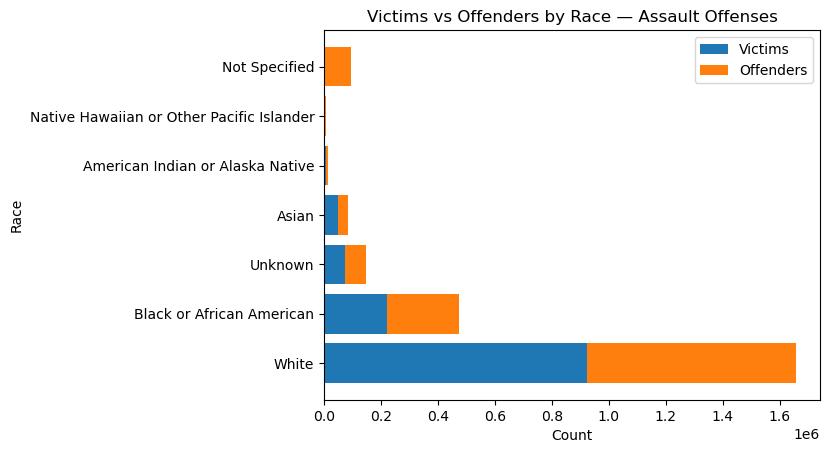

In [90]:
# Cell 45 — Victim vs Offender race comparison (Assault Offenses)

assault_compare = victim_vs_offender_race[
    victim_vs_offender_race["offense_category_name"] == "Assault Offenses"
]

plt.figure()
plt.barh(assault_compare["race"], assault_compare["victim_count"], label="Victims")
plt.barh(assault_compare["race"], assault_compare["offender_count"], left=assault_compare["victim_count"], label="Offenders")
plt.xlabel("Count")
plt.ylabel("Race")
plt.title("Victims vs Offenders by Race — Assault Offenses")
plt.legend()
plt.show()


In [91]:
# Cell 46 — Top locations for selected offense categories

location_by_category = (
    offense_view[
        offense_view["offense_category_name"].isin(top_offense_categories)
    ]
    .groupby(["offense_category_name", "location_name"])
    .size()
    .reset_index(name="offense_count")
    .sort_values(["offense_category_name", "offense_count"], ascending=[True, False])
)

location_by_category.head(10)


,offense_category_name,location_name,offense_count
35,Assault Offenses,Residence/Home,545996
24,Assault Offenses,Highway/Road/Alley/Street/Sidewalk,186925
31,Assault Offenses,Other/Unknown,58482
33,Assault Offenses,Parking/Drop Lot/Garage,53499
39,Assault Offenses,School-Elementary/Secondary,32107
18,Assault Offenses,Drug Store/Doctor's Office/Hospital,29123
25,Assault Offenses,Hotel/Motel/Etc.,21339
27,Assault Offenses,Jail/Prison/Penitentiary/Corrections Facility,20283
37,Assault Offenses,Restaurant,17988
32,Assault Offenses,Park/Playground,15456


In [92]:
######### KHUE DINH's contribution #################
# In[62]: KHUE DINH
    
# Cell 47 - Create a monthly demand table (state x year x month)
import pandas as pd
import numpy as np

df = offense_view.copy()

# Build month/year from incident_date (reliable; month_num column is mostly missing)
df["incident_date"] = pd.to_datetime(df["incident_date"], errors="coerce")

df["data_year"] = df["incident_date"].dt.year
df["month_num"] = df["incident_date"].dt.month

# Drop rows missing essentials
df = df.dropna(subset=["state", "data_year", "month_num"]).copy()

df["data_year"] = df["data_year"].astype(int)
df["month_num"] = df["month_num"].astype(int)

# Monthly target: number of offenses per state-month
monthly = (
    df.groupby(["state", "data_year", "month_num"], as_index=False)
      .size()
      .rename(columns={"size": "crime_count"})
)

monthly["year_month"] = pd.to_datetime(
    monthly["data_year"].astype(str) + "-" + monthly["month_num"].astype(str) + "-01"
)

monthly = monthly.sort_values(["state", "year_month"]).reset_index(drop=True)

# Sanity checks
print("Monthly rows per state:")
print(monthly.groupby("state").size())

monthly.head()



Monthly rows per state:
state
CA    48
ID    48
MA    48
NJ    48
dtype: int64


,state,data_year,month_num,crime_count,year_month
0,CA,2021,1,9956,2021-01-01
1,CA,2021,2,11429,2021-02-01
2,CA,2021,3,11597,2021-03-01
3,CA,2021,4,11367,2021-04-01
4,CA,2021,5,12088,2021-05-01


In [93]:
# In[63]:
    
# Cell 48: Create prediction features (lags, rolling means, seasonaiity) 

# Always sort first so lag/rolling are computed correctly
monthly = monthly.sort_values(["state", "year_month"]).reset_index(drop=True)

# Lags: previous months (past info only)
monthly["lag_1"] = monthly.groupby("state")["crime_count"].shift(1)
monthly["lag_2"] = monthly.groupby("state")["crime_count"].shift(2)
monthly["lag_3"] = monthly.groupby("state")["crime_count"].shift(3)

# Rolling averages (trend smoothing). shift(1) prevents leakage.
monthly["roll_mean_3"] = (
    monthly.groupby("state")["crime_count"]
    .shift(1)
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

monthly["roll_mean_6"] = (
    monthly.groupby("state")["crime_count"]
    .shift(1)
    .rolling(6)
    .mean()
    .reset_index(level=0, drop=True)
)

# Month seasonality as cyclical features
monthly["month_sin"] = np.sin(2 * np.pi * monthly["month_num"] / 12)
monthly["month_cos"] = np.cos(2 * np.pi * monthly["month_num"] / 12)

# Keep only rows where we have enough history for features
# (roll_mean_6 is the strictest: needs 6 prior months)
model_df = monthly.dropna(subset=["lag_1", "lag_2", "lag_3", "roll_mean_3", "roll_mean_6"]).reset_index(drop=True)

# Sanity check: should be 48-6 = 42 rows per state
print("Rows per state in model_df:")
print(model_df.groupby("state").size())

model_df.head()


Rows per state in model_df:
state
CA    42
ID    42
MA    42
NJ    42
dtype: int64


,state,data_year,month_num,crime_count,year_month,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_6,month_sin,month_cos
0,CA,2021,7,12267,2021-07-01,11429.0,12088.0,11367.0,11628.000000,11311.000000,-0.500000,-8.660254e-01
1,CA,2021,8,11517,2021-08-01,12267.0,11429.0,12088.0,11928.000000,11696.166667,-0.866025,-5.000000e-01
2,CA,2021,9,11531,2021-09-01,11517.0,12267.0,11429.0,11737.666667,11710.833333,-1.000000,-1.836970e-16
3,CA,2021,10,11834,2021-10-01,11531.0,11517.0,12267.0,11771.666667,11699.833333,-0.866025,5.000000e-01
4,CA,2021,11,10931,2021-11-01,11834.0,11531.0,11517.0,11627.333333,11777.666667,-0.500000,8.660254e-01


In [94]:
# In[64]:
    
# Cell 49: Add crime composition features (Person/Property/Society)


# Use your original offense_view (offense-level) for this
base = offense_view.copy()

# Derive month/year from incident_date (month_num column is not reliable)
base["incident_date"] = pd.to_datetime(base["incident_date"], errors="coerce")
base["data_year"] = base["incident_date"].dt.year
base["month_num"] = base["incident_date"].dt.month

# Keep only rows with required fields
base = base.dropna(subset=["state", "data_year", "month_num", "crime_against"]).copy()
base["data_year"] = base["data_year"].astype(int)
base["month_num"] = base["month_num"].astype(int)

# Count offenses by crime_against per state-month
mix = (
    base.groupby(["state", "data_year", "month_num", "crime_against"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
)

# Guarantee expected columns exist
for col in ["Person", "Property", "Society"]:
    if col not in mix.columns:
        mix[col] = 0

# Convert counts into percentages
mix_total = mix[["Person", "Property", "Society"]].sum(axis=1).replace(0, np.nan)

mix["pct_person"] = (mix["Person"] / mix_total).fillna(0)
mix["pct_property"] = (mix["Property"] / mix_total).fillna(0)
mix["pct_society"] = (mix["Society"] / mix_total).fillna(0)

mix = mix[["state", "data_year", "month_num", "pct_person", "pct_property", "pct_society"]]

# Merge into model_df (model_df is state-month already)
model_df = model_df.merge(mix, on=["state", "data_year", "month_num"], how="left")

# Fill any missing with 0 (rare)
model_df[["pct_person", "pct_property", "pct_society"]] = (
    model_df[["pct_person", "pct_property", "pct_society"]].fillna(0)
)

# Sanity check: composition should sum to ~1 for most rows
model_df["pct_sum"] = model_df["pct_person"] + model_df["pct_property"] + model_df["pct_society"]
print("pct_sum min/mean/max:", model_df["pct_sum"].min(), model_df["pct_sum"].mean(), model_df["pct_sum"].max())

model_df.head()



pct_sum min/mean/max: 0.9999999999999999 1.0 1.0000000000000002


,state,data_year,month_num,crime_count,year_month,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_6,month_sin,month_cos,pct_person,pct_property,pct_society,pct_sum
0,CA,2021,7,12267,2021-07-01,11429.0,12088.0,11367.0,11628.000000,11311.000000,-0.500000,-8.660254e-01,0.232983,0.570148,0.196870,1.0
1,CA,2021,8,11517,2021-08-01,12267.0,11429.0,12088.0,11928.000000,11696.166667,-0.866025,-5.000000e-01,0.235738,0.573500,0.190761,1.0
2,CA,2021,9,11531,2021-09-01,11517.0,12267.0,11429.0,11737.666667,11710.833333,-1.000000,-1.836970e-16,0.229382,0.588761,0.181858,1.0
3,CA,2021,10,11834,2021-10-01,11531.0,11517.0,12267.0,11771.666667,11699.833333,-0.866025,5.000000e-01,0.220382,0.612219,0.167399,1.0
4,CA,2021,11,10931,2021-11-01,11834.0,11531.0,11517.0,11627.333333,11777.666667,-0.500000,8.660254e-01,0.212515,0.624646,0.162840,1.0


In [95]:
# In[65]:

# Cell 50: Train/test split (2021-2023 train, 2024 test)

# Make sure year_month is datetime
model_df["year_month"] = pd.to_datetime(model_df["year_month"])

cutoff = pd.Timestamp("2024-01-01")

train_df = model_df[model_df["year_month"] < cutoff].copy()
test_df  = model_df[model_df["year_month"] >= cutoff].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train states:", sorted(train_df["state"].unique()))
print("Test states:", sorted(test_df["state"].unique()))

# Optional: confirm date ranges
print("\nTrain date range:", train_df["year_month"].min(), "to", train_df["year_month"].max())
print("Test date range:", test_df["year_month"].min(), "to", test_df["year_month"].max())



Train rows: 120
Test rows: 48
Train states: ['CA', 'ID', 'MA', 'NJ']
Test states: ['CA', 'ID', 'MA', 'NJ']

Train date range: 2021-07-01 00:00:00 to 2023-12-01 00:00:00
Test date range: 2024-01-01 00:00:00 to 2024-12-01 00:00:00


In [96]:
# In[66]:
    
# Cell 51: Train regression model and create pred_df

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features (X) and target (y)
feature_cols = [
    "state", "data_year", "month_num",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3",
    "roll_mean_3", "roll_mean_6",
    "pct_person", "pct_property", "pct_society"
]

X_train = train_df[feature_cols]
y_train = train_df["crime_count"]

X_test = test_df[feature_cols]
y_test = test_df["crime_count"]

# One-hot encode state, pass numeric through
prep = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["state"]),
        ("num", "passthrough", [c for c in feature_cols if c != "state"]),
    ]
)

ridge = Pipeline(steps=[
    ("prep", prep),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)
print(f"Ridge -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R2: {r2:.3f}")

# Prediction table
pred_df = test_df[["state", "year_month", "crime_count"]].copy()
pred_df["predicted_crime"] = pred

pred_df.head()

Ridge -> MAE: 1,972.63 | RMSE: 2,843.47 | R2: 0.996


,state,year_month,crime_count,predicted_crime
30,CA,2024-01-01,108678,101549.803763
31,CA,2024-02-01,101756,108831.553107
32,CA,2024-03-01,111024,107553.575153
33,CA,2024-04-01,110337,109187.637109
34,CA,2024-05-01,119698,112260.259501


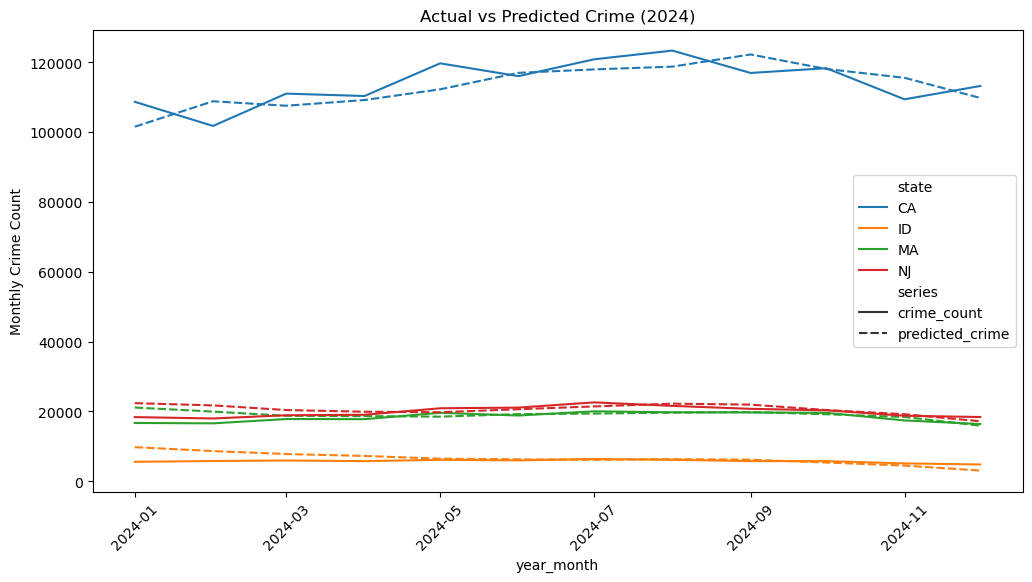

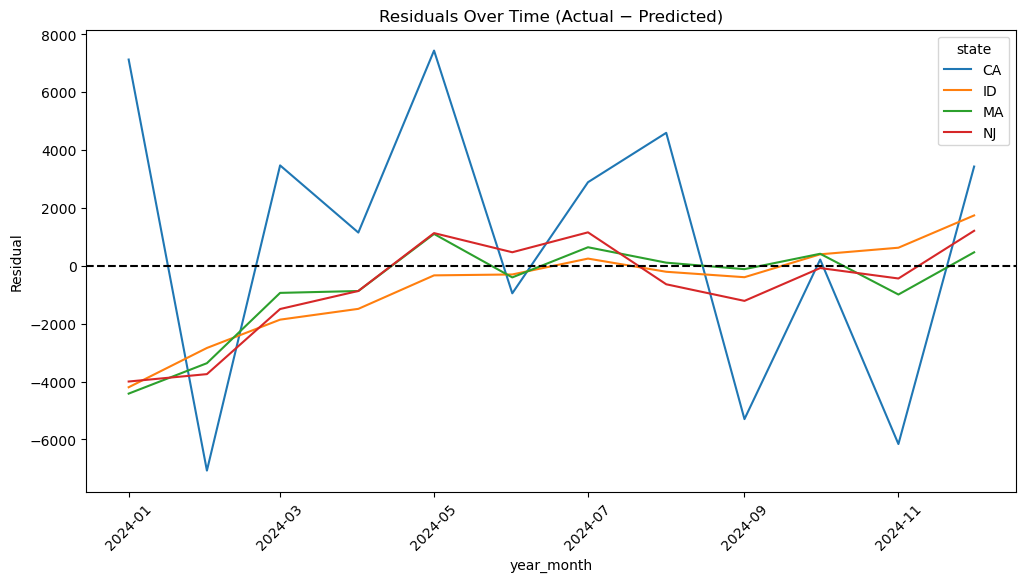

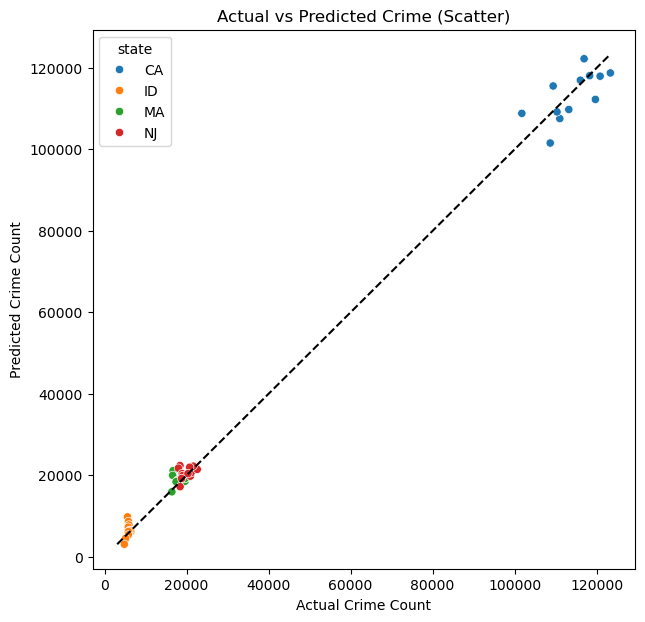

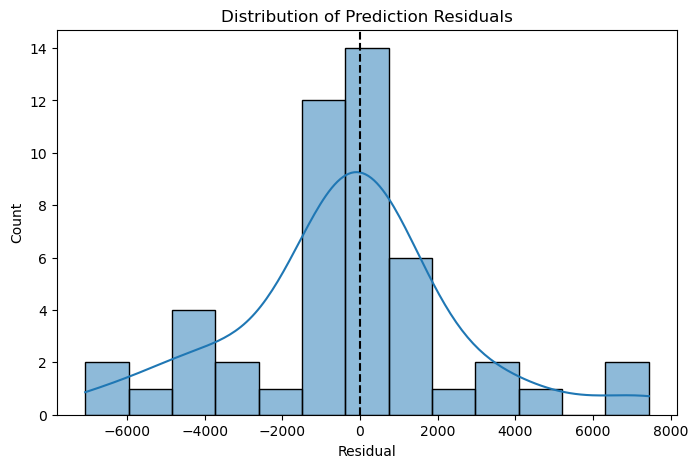

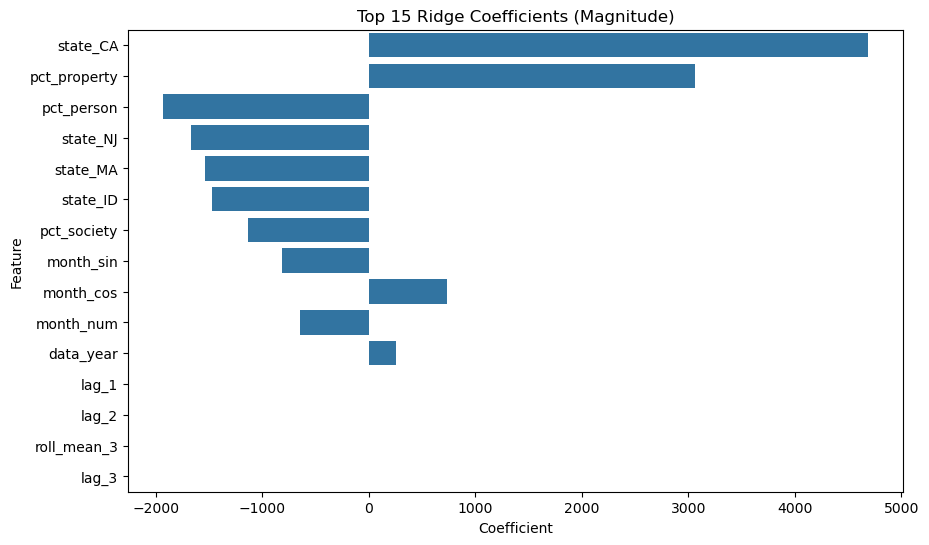

,feature,coefficient,abs_coef
0,state_CA,4683.896001,4683.896001
14,pct_property,3065.283421,3065.283421
13,pct_person,-1931.249270,1931.249270
3,state_NJ,-1668.667414,1668.667414
2,state_MA,-1541.532536,1541.532536
1,state_ID,-1473.696051,1473.696051
15,pct_society,-1134.034151,1134.034151
6,month_sin,-817.337727,817.337727
7,month_cos,734.027746,734.027746
5,month_num,-648.124215,648.124215


In [97]:
# In[67]:
    
# Cell 52: Plot predicted vs actual overtime
import matplotlib.pyplot as plt
import seaborn as sns

plot_pred = pred_df.melt(
    id_vars=["state", "year_month"],
    value_vars=["crime_count", "predicted_crime"],
    var_name="series",
    value_name="value"
)

plt.figure(figsize=(12,6))
sns.lineplot(data=plot_pred, x="year_month", y="value", hue="state", style="series")
plt.title("Actual vs Predicted Crime (2024)")
plt.ylabel("Monthly Crime Count")
plt.xticks(rotation=45)
plt.show()


# In[68]:

# Cell 53: Residuals over time
pred_df["residual"] = pred_df["crime_count"] - pred_df["predicted_crime"]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=pred_df,
    x="year_month",
    y="residual",
    hue="state"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals Over Time (Actual − Predicted)")
plt.ylabel("Residual")
plt.xticks(rotation=45)
plt.show()

# In[69]:

# Cell 54: Actual vs Predicted scatter
plt.figure(figsize=(7,7))
sns.scatterplot(
    data=pred_df,
    x="crime_count",
    y="predicted_crime",
    hue="state"
)

# 45-degree reference line
lims = [
    pred_df[["crime_count","predicted_crime"]].min().min(),
    pred_df[["crime_count","predicted_crime"]].max().max()
]
plt.plot(lims, lims, "--", color="black")

plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Actual vs Predicted Crime (Scatter)")
plt.show()

# In[70]:

# Cell 55: Residual distribution
plt.figure(figsize=(8,5))
sns.histplot(pred_df["residual"], kde=True)
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual")
plt.show()

# In[71]:
    
# Cell 56: Ridge coefficients (works with your Pipeline + ColumnTransformer)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1) Get the trained ridge model inside the pipeline
ridge_model = ridge.named_steps["model"]

# 2) Get feature names after preprocessing (one-hot expands state)
ohe = ridge.named_steps["prep"].named_transformers_["cat"]
state_feature_names = ohe.get_feature_names_out(["state"])

numeric_feature_names = np.array([c for c in feature_cols if c != "state"], dtype=object)

all_feature_names = np.concatenate([state_feature_names, numeric_feature_names])

# 3) Build coefficient dataframe
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": ridge_model.coef_
})

# Optional: add absolute value for sorting
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

# 4) Plot top N coefficients for readability
top_n = 15
top_coef = coef_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_coef, x="coefficient", y="feature")
plt.title(f"Top {top_n} Ridge Coefficients (Magnitude)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

coef_df.head(20)




In [98]:
# In[72]:

# Cell 57: Build within-state demand + Efficiency allocation (SciPy only)

import numpy as np
import pandas as pd
from scipy.optimize import linprog

# 1) Build within-state demand (uses predicted crime + historical composition)
within_df = pred_df.merge(
    model_df[["state","year_month","pct_person","pct_property","pct_society"]],
    on=["state","year_month"],
    how="left"
).copy()

# Safety: if any missing, fill with 0 then renormalize (rare, but makes code robust)
within_df[["pct_person","pct_property","pct_society"]] = within_df[["pct_person","pct_property","pct_society"]].fillna(0)
row_sum = within_df[["pct_person","pct_property","pct_society"]].sum(axis=1).replace(0, np.nan)
within_df["pct_person"]   = (within_df["pct_person"] / row_sum).fillna(0)
within_df["pct_property"] = (within_df["pct_property"] / row_sum).fillna(0)
within_df["pct_society"]  = (within_df["pct_society"] / row_sum).fillna(0)

within_df["crime_person"]   = within_df["predicted_crime"] * within_df["pct_person"]
within_df["crime_property"] = within_df["predicted_crime"] * within_df["pct_property"]
within_df["crime_society"]  = within_df["predicted_crime"] * within_df["pct_society"]

# 2) Assumptions
impact = {"person": 0.004, "property": 0.007, "society": 0.003}
units_per_state = 25
min_units_type = 3

# 3) Efficiency optimization (maximize reduction)
results_eff = []

for (state, month), g in within_df.groupby(["state", "year_month"]):
    row = g.iloc[0]

    b_person   = float(row["crime_person"]   * impact["person"])
    b_property = float(row["crime_property"] * impact["property"])
    b_society  = float(row["crime_society"]  * impact["society"])

    c = -np.array([b_person, b_property, b_society])  # maximize -> minimize negative

    A_ub = np.array([[1, 1, 1]])
    b_ub = np.array([units_per_state])

    bounds = [(min_units_type, None),
              (min_units_type, None),
              (min_units_type, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"Efficiency optimization failed for {state} {month}: {res.message}")

    results_eff.append({
        "state": state,
        "year_month": month,
        "units_person": res.x[0],
        "units_property": res.x[1],
        "units_society": res.x[2]
    })

within_alloc = pd.DataFrame(results_eff)

# Quick sanity check
within_alloc.head()

,state,year_month,units_person,units_property,units_society
0,CA,2024-01-01,3.0,19.0,3.0
1,CA,2024-02-01,3.0,19.0,3.0
2,CA,2024-03-01,3.0,19.0,3.0
3,CA,2024-04-01,3.0,19.0,3.0
4,CA,2024-05-01,3.0,19.0,3.0


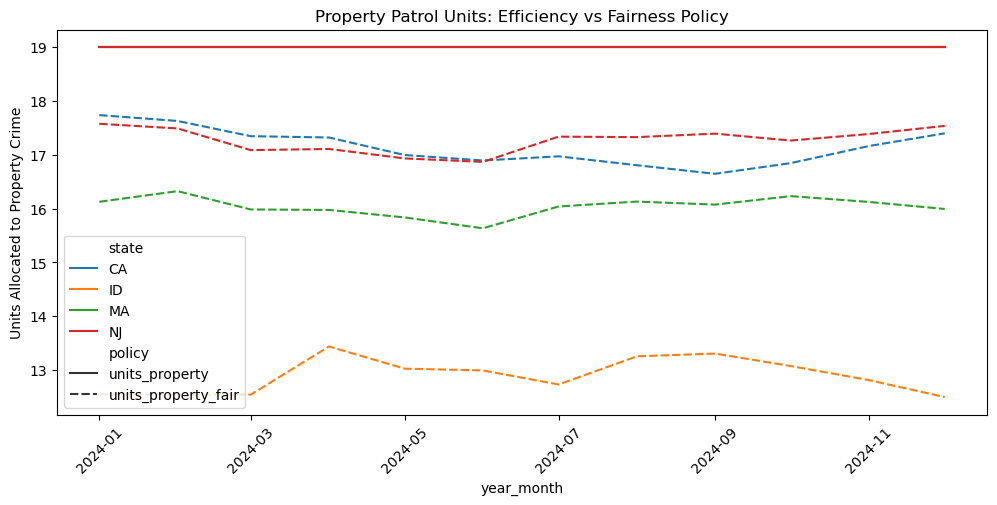

,state,year_month,units_person,units_property,units_society,units_person_fair,units_property_fair,units_society_fair,alpha,eff_person_change,eff_property_change,eff_society_change
0,CA,2024-01-01,3.0,19.0,3.0,3.883767,17.735972,3.380261,0.8,0.883767,-1.264028,0.380261
1,CA,2024-02-01,3.0,19.0,3.0,4.028264,17.627069,3.344668,0.8,1.028264,-1.372931,0.344668
2,CA,2024-03-01,3.0,19.0,3.0,4.181979,17.344358,3.473663,0.8,1.181979,-1.655642,0.473663
3,CA,2024-04-01,3.0,19.0,3.0,4.376592,17.320074,3.303334,0.8,1.376592,-1.679926,0.303334
4,CA,2024-05-01,3.0,19.0,3.0,4.702167,16.994185,3.303648,0.8,1.702167,-2.005815,0.303648


In [99]:
# In[73]:

# Cell 58: Fairness optimization + compare + visualization

import seaborn as sns
import matplotlib.pyplot as plt

alpha = 0.8  # fairness strength

results_fair = []

for (state, month), g in within_df.groupby(["state", "year_month"]):
    row = g.iloc[0]

    b_person   = float(row["crime_person"]   * impact["person"])
    b_property = float(row["crime_property"] * impact["property"])
    b_society  = float(row["crime_society"]  * impact["society"])

    c = -np.array([b_person, b_property, b_society])

    A_ub = np.array([[1, 1, 1]])
    b_ub = np.array([units_per_state])

    # Fairness lower bounds proportional to crime mix (with absolute minimum floor)
    lb_person   = max(min_units_type, alpha * units_per_state * float(row["pct_person"]))
    lb_property = max(min_units_type, alpha * units_per_state * float(row["pct_property"]))
    lb_society  = max(min_units_type, alpha * units_per_state * float(row["pct_society"]))

    # Feasibility guard: if bounds sum exceeds total units, reduce alpha or min_units_type
    if (lb_person + lb_property + lb_society) > units_per_state:
        raise ValueError(
            f"Infeasible bounds for {state} {month}. "
            f"Try smaller alpha or smaller min_units_type."
        )

    bounds = [(lb_person, None), (lb_property, None), (lb_society, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"Fairness optimization failed for {state} {month}: {res.message}")

    results_fair.append({
        "state": state,
        "year_month": month,
        "units_person_fair": res.x[0],
        "units_property_fair": res.x[1],
        "units_society_fair": res.x[2],
        "alpha": alpha
    })

fair_within_alloc = pd.DataFrame(results_fair)

# Compare Efficiency vs Fairness
compare = within_alloc.merge(fair_within_alloc, on=["state", "year_month"], how="inner")

compare["eff_person_change"] = compare["units_person_fair"] - compare["units_person"]
compare["eff_property_change"] = compare["units_property_fair"] - compare["units_property"]
compare["eff_society_change"] = compare["units_society_fair"] - compare["units_society"]

# Visualization: property units under both policies
plot_df = compare.melt(
    id_vars=["state", "year_month"],
    value_vars=["units_property", "units_property_fair"],
    var_name="policy",
    value_name="units"
)

plt.figure(figsize=(12,5))
sns.lineplot(data=plot_df, x="year_month", y="units", hue="state", style="policy")
plt.title("Property Patrol Units: Efficiency vs Fairness Policy")
plt.xticks(rotation=45)
plt.ylabel("Units Allocated to Property Crime")
plt.show()

compare.head()